STEP 1. 데이터 및 모델 불러오기
RSF 모델     : RandomSurvivalForest
GBM 모델     : GradientBoostingSurvivalAnalysis
피처 수      : 14개
Train        : 930명
Test         : 233명
배경 데이터  : 100개

피처 목록:
  Age
  Sex
  Prior_cancer
  Grade_G2
  Grade_G3
  Grade_G4
  Site_BrainNOS
  Site_Cerebrum
  Site_Other
  Era_After2005
  Era_Before2005
  Tx_Single
  Tx_Standard
  Tx_None

STEP 2. PFI (Permutation Feature Importance)
변수를 섞었을 때 C-index 하락 = 변수 중요도
RSF + GBM 각각 계산 후 비교

[ RSF PFI ]
  Age                 : +0.0697 ± 0.0141
  Sex                 : -0.0002 ± 0.0029
  Prior_cancer        : -0.0001 ± 0.0003
  Grade_G2            : +0.0027 ± 0.0014
  Grade_G3            : +0.0006 ± 0.0008
  Grade_G4            : +0.0771 ± 0.0128
  Site_BrainNOS       : +0.0070 ± 0.0041
  Site_Cerebrum       : +0.0007 ± 0.0021
  Site_Other          : +0.0000 ± 0.0000
  Era_After2005       : +0.0012 ± 0.0020
  Era_Before2005      : +0.0008 ± 0.0020
  Tx_Single           : +0.0061 ± 0.0018
  Tx_Standard         : +0.0001 ± 0.0018
  

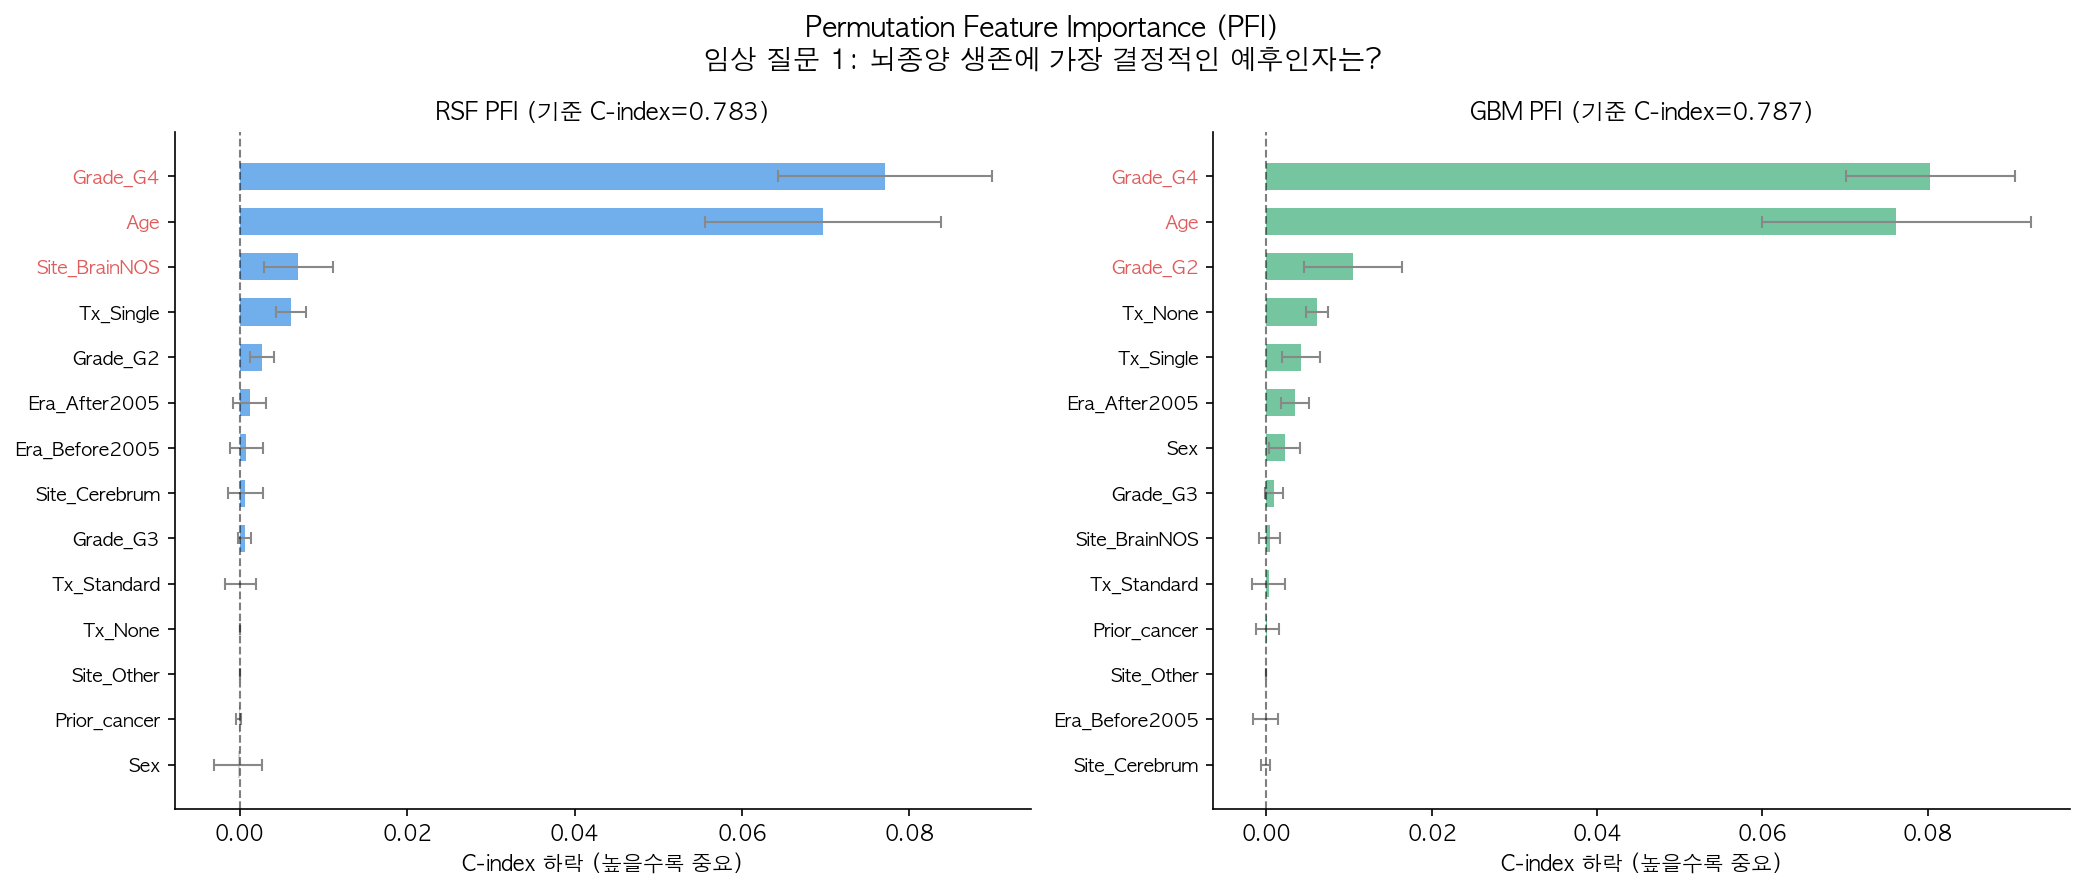

✓ fig_pfi_comparison.png 저장 완료

STEP 3. SHAP Summary Plot
각 변수의 기여도 방향(+/-) + 크기를 동시에 시각화

  RSF SHAP 계산 중... (배경 100개, 평가 233개)


PermutationExplainer explainer: 234it [16:29,  4.28s/it]                                            


  ✓ RSF SHAP 완료

  GBM SHAP 계산 중... (배경 100개, 평가 233개)
  ✓ GBM SHAP 완료


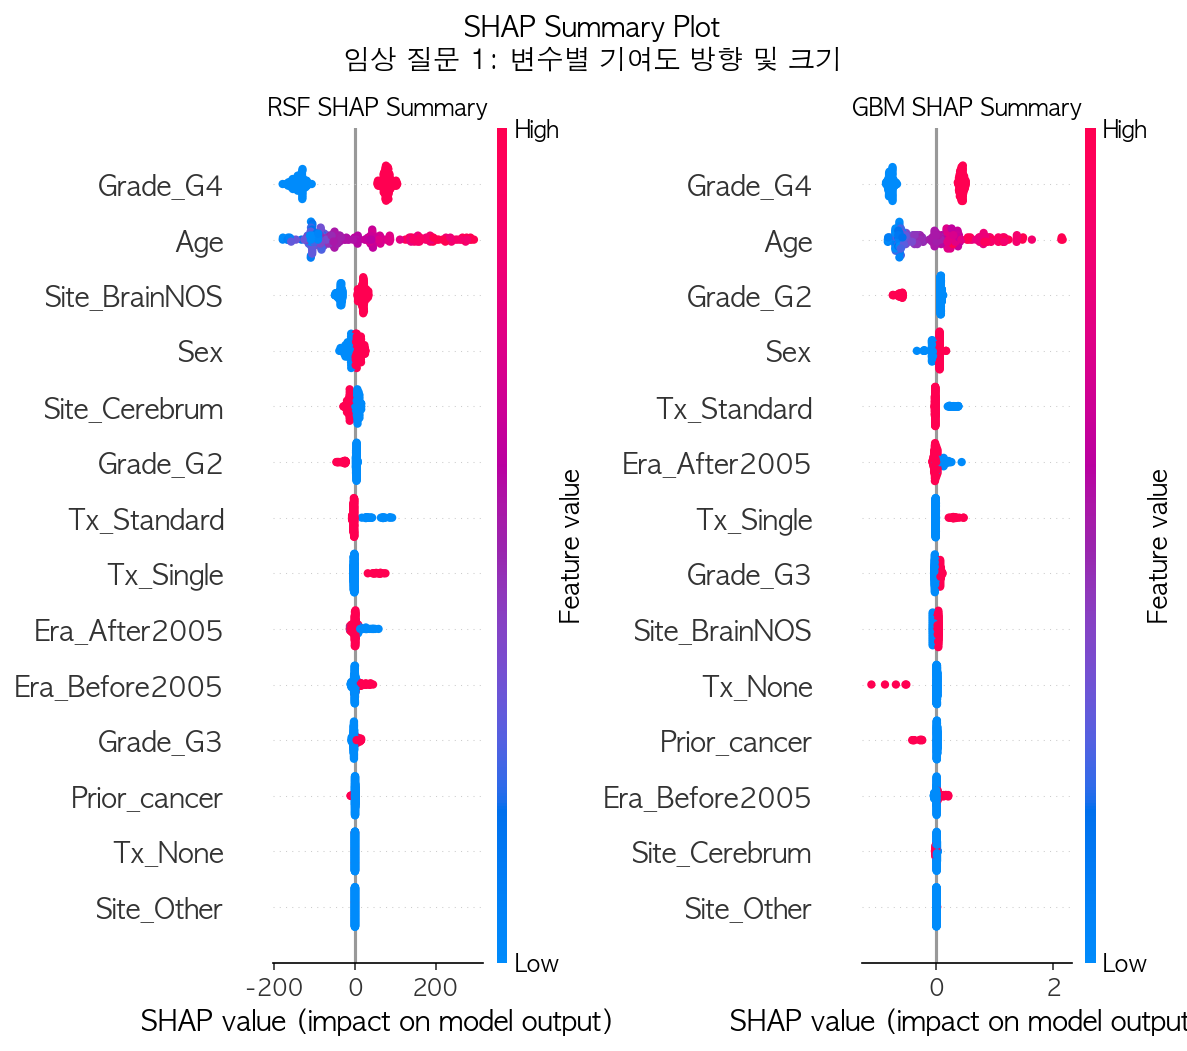

✓ fig_shap_summary.png 저장 완료
✓ table_shap_rsf.csv / table_shap_gbm.csv 저장 완료

STEP 4. ALE Plot
변수 값 변화에 따른 예측 변화 (상관 변수 보정)
Langbein et al.(2025) 권고: PDP 대신 ALE 적용


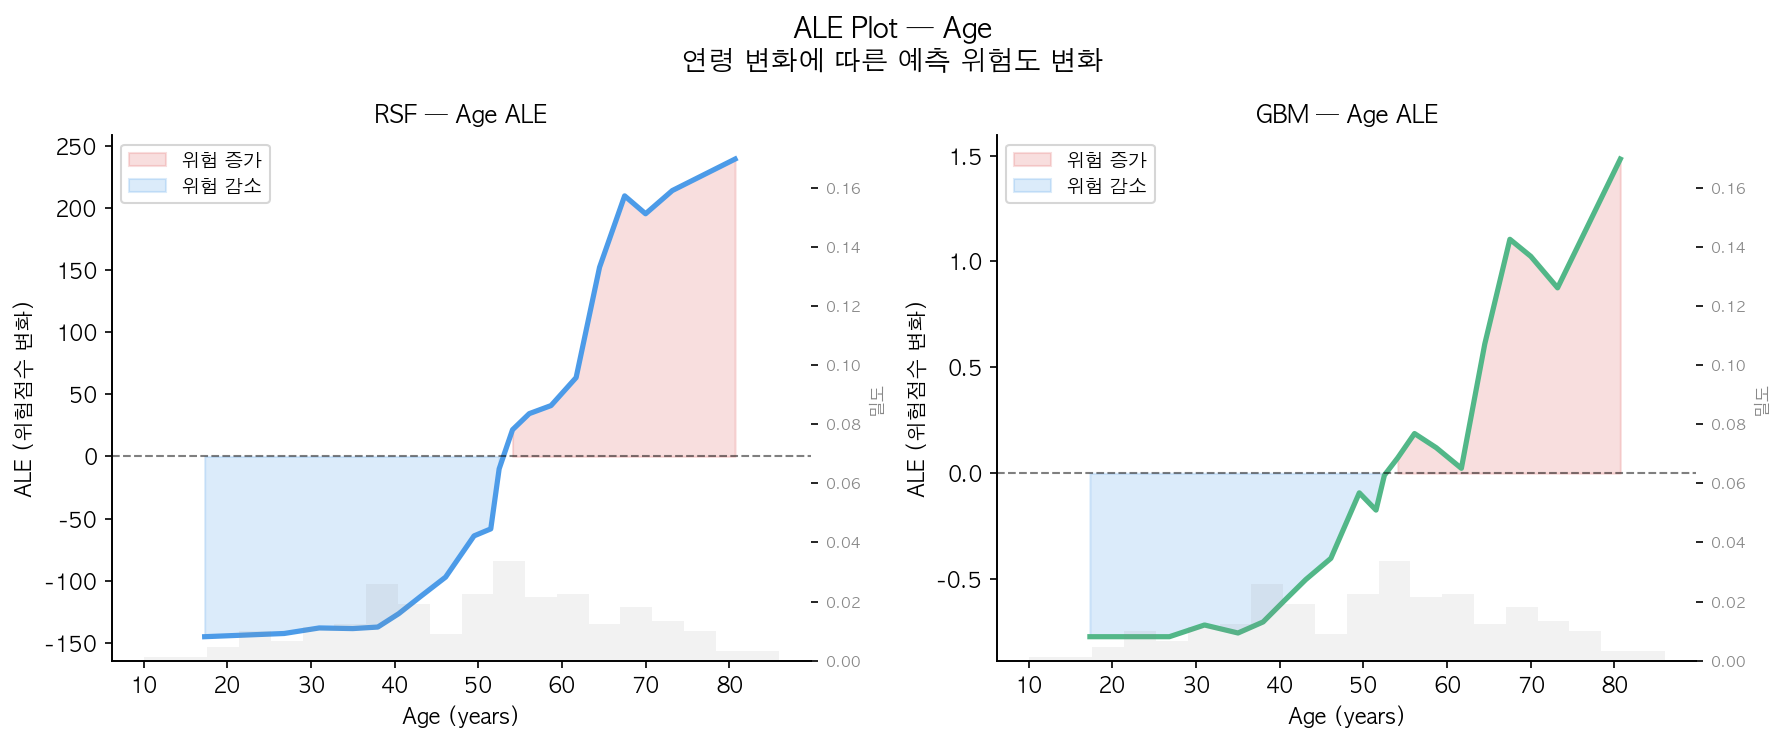

✓ fig_ale_age.png 저장 완료

[ 범주형 변수 SHAP Bar Plot (ALE 대체) ]


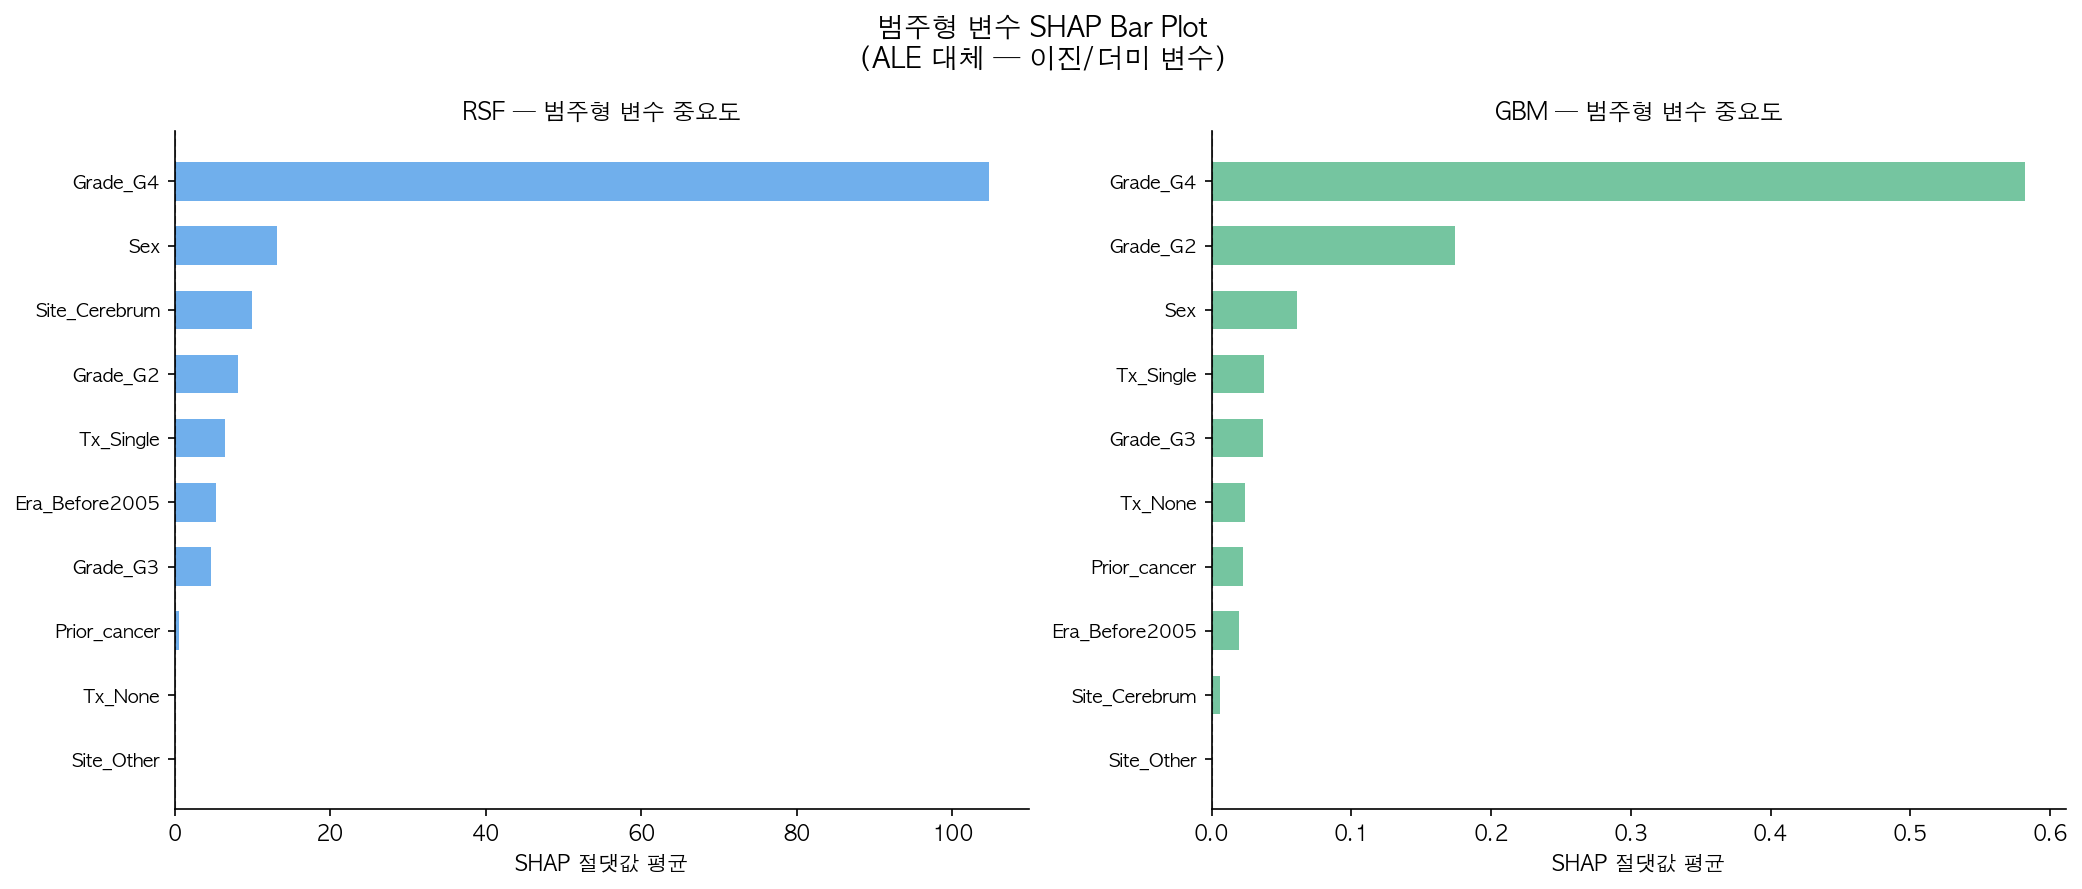

✓ fig_shap_bar_categorical.png 저장 완료

STEP 5. 변수 중요도 종합 비교

=== 변수 중요도 종합 순위 ===
       Feature  PFI_RSF  PFI_GBM  SHAP_RSF  SHAP_GBM  Avg_Rank
      Grade_G4   0.0771   0.0803  104.6512    0.5823       1.0
           Age   0.0697   0.0762  103.9613    0.5345       2.0
      Grade_G2   0.0027   0.0105    8.1517    0.1745       4.2
 Site_BrainNOS   0.0070   0.0004   26.0283    0.0346       6.0
     Tx_Single   0.0061   0.0042    6.4307    0.0374       6.0
 Era_After2005   0.0012   0.0035    6.1602    0.0449       6.8
           Sex  -0.0002   0.0022   13.1451    0.0613       7.2
   Tx_Standard   0.0001   0.0003    7.9129    0.0481       8.0
      Grade_G3   0.0006   0.0009    4.6125    0.0366       9.0
       Tx_None   0.0000   0.0061    0.0000    0.0237       9.5
 Site_Cerebrum   0.0007  -0.0001    9.9709    0.0062       9.8
Era_Before2005   0.0008  -0.0001    5.2793    0.0195      10.5
  Prior_cancer  -0.0001   0.0001    0.5167    0.0227      11.8
    Site_Other   0.0000   0.0000    0

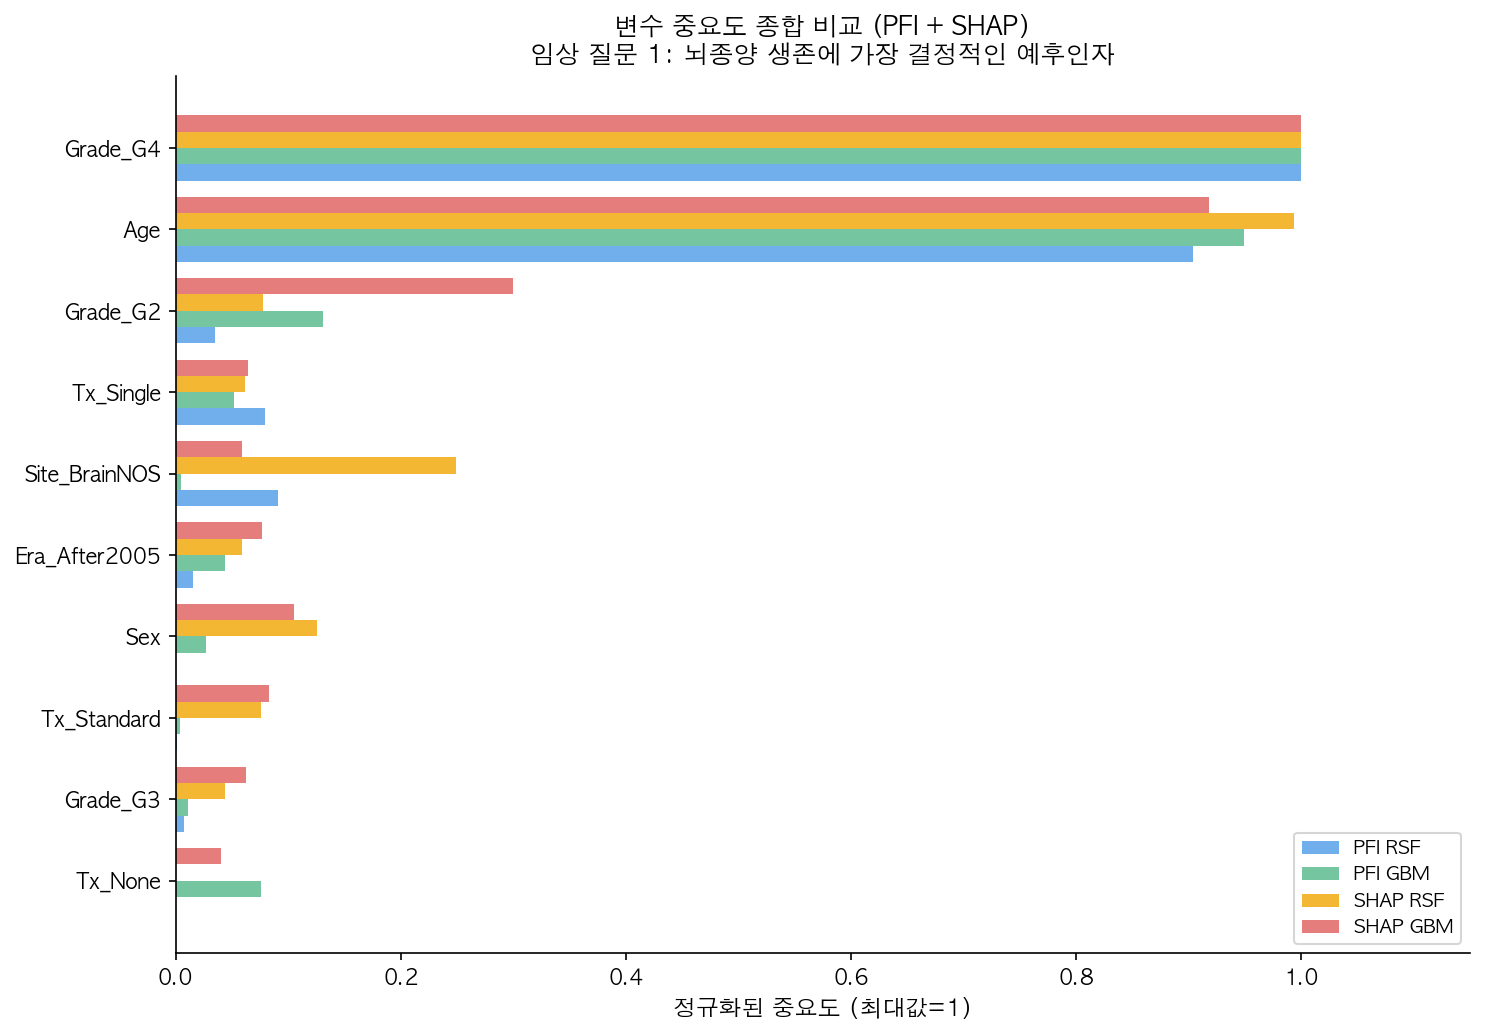

✓ fig_feature_importance_combined.png 저장 완료

STEP 6. 결과 저장
✓ global_xai.pkl 저장 완료
  → NB 06 Local XAI에서 바로 불러와 사용

NB 05 완료 — Global XAI 요약

[ 임상 질문 1: 가장 중요한 예후인자 ]
  RSF PFI Top 3: ['Grade_G4', 'Age', 'Site_BrainNOS']
  GBM PFI Top 3: ['Grade_G4', 'Age', 'Grade_G2']
  SHAP Top 3 (RSF): ['Grade_G4', 'Age', 'Site_BrainNOS']
  종합 1위: Grade_G4


→ 다음: NB 06 Local XAI (개별 환자 설명)


In [4]:
# ============================================================
# NB 05. Global XAI — PFI + SHAP Summary + ALE
# Brain Tumor Survival Analysis — Explainable AI
#
# 임상 질문 1: 뇌종양 생존에 가장 결정적인 예후인자는?
#
# STEP 1. 데이터 및 모델 불러오기
# STEP 2. PFI (Permutation Feature Importance)
# STEP 3. SHAP Summary Plot
# STEP 4. ALE Plot (Accumulated Local Effects)
# STEP 5. 변수 중요도 종합 비교
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import joblib
import warnings
import os
warnings.filterwarnings('ignore')

import shap
from sksurv.metrics import concordance_index_censored

plt.rcParams.update({
    'font.family'      : 'AppleGothic',
    'axes.unicode_minus': False,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

OUTPUT_DIR = "./outputs/"
MODEL_DIR  = "./outputs/models/"
SEED       = 42
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)
np.random.seed(SEED)

# ============================================================
# STEP 1. 데이터 및 모델 불러오기
# ============================================================

print("="*55)
print("STEP 1. 데이터 및 모델 불러오기")
print("="*55)

ml_data     = joblib.load(MODEL_DIR + "ml_models.pkl")
rsf_best    = ml_data['rsf_best']
gbm_best    = ml_data['gbm_best']
ML_FEATURES = ml_data['ml_features']
X_train     = ml_data['X_train']
X_test      = ml_data['X_test']
y_train     = ml_data['y_train']
y_test      = ml_data['y_test']
times       = ml_data['times']
X_background = ml_data['X_background']   # SHAP 배경 데이터 100개

print(f"RSF 모델     : {rsf_best.__class__.__name__}")
print(f"GBM 모델     : {gbm_best.__class__.__name__}")
print(f"피처 수      : {len(ML_FEATURES)}개")
print(f"Train        : {len(X_train):,}명")
print(f"Test         : {len(X_test):,}명")
print(f"배경 데이터  : {len(X_background)}개")
print(f"\n피처 목록:")
for col in ML_FEATURES:
    print(f"  {col}")

# ============================================================
# STEP 2. PFI (Permutation Feature Importance)
# ============================================================
# 변수를 무작위로 섞었을 때 C-index 하락 정도 = 변수 중요도
# Langbein et al.(2025) 권고 방법

print("\n" + "="*55)
print("STEP 2. PFI (Permutation Feature Importance)")
print("="*55)
print("변수를 섞었을 때 C-index 하락 = 변수 중요도")
print("RSF + GBM 각각 계산 후 비교\n")

N_REPEATS = 10  # 안정성을 위해 10회 반복 평균

def compute_pfi(model, X, y, feature_cols, n_repeats=10, seed=42):
    """
    Permutation Feature Importance 계산
    각 변수를 n_repeats번 섞어서 C-index 하락 평균
    """
    rng = np.random.RandomState(seed)

    # 기준 C-index
    base_risk = model.predict(X)
    base_c    = concordance_index_censored(
        y['event'], y['time'], base_risk
    )[0]

    results = []
    for col in feature_cols:
        drops = []
        for _ in range(n_repeats):
            X_perm       = X.copy()
            X_perm[col]  = rng.permutation(X_perm[col].values)
            perm_risk    = model.predict(X_perm)
            perm_c       = concordance_index_censored(
                y['event'], y['time'], perm_risk
            )[0]
            drops.append(base_c - perm_c)

        results.append({
            'Feature'      : col,
            'Importance'   : round(float(np.mean(drops)), 4),
            'Importance_std': round(float(np.std(drops)), 4),
        })
        print(f"  {col:20s}: {np.mean(drops):+.4f} ± {np.std(drops):.4f}")

    df_pfi = (
        pd.DataFrame(results)
          .sort_values('Importance', ascending=False)
          .reset_index(drop=True)
    )
    print(f"\n기준 C-index: {base_c:.3f}")
    return df_pfi, base_c

# RSF PFI
print("[ RSF PFI ]")
df_pfi_rsf, base_c_rsf = compute_pfi(
    rsf_best, X_test, y_test, ML_FEATURES,
    n_repeats=N_REPEATS, seed=SEED
)

print("\n[ GBM PFI ]")
df_pfi_gbm, base_c_gbm = compute_pfi(
    gbm_best, X_test, y_test, ML_FEATURES,
    n_repeats=N_REPEATS, seed=SEED
)

# PFI 저장
df_pfi_rsf.to_csv(
    OUTPUT_DIR + "table_pfi_rsf.csv",
    index=False, encoding='utf-8-sig'
)
df_pfi_gbm.to_csv(
    OUTPUT_DIR + "table_pfi_gbm.csv",
    index=False, encoding='utf-8-sig'
)
print("\n✓ table_pfi_rsf.csv / table_pfi_gbm.csv 저장 완료")

# PFI 시각화 — RSF + GBM 나란히
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Permutation Feature Importance (PFI)\n"
    "임상 질문 1: 뇌종양 생존에 가장 결정적인 예후인자는?",
    fontsize=13, fontweight='bold'
)

for ax, df_pfi, model_name, color in zip(
    axes,
    [df_pfi_rsf, df_pfi_gbm],
    ['RSF', 'GBM'],
    ['#4C9BE8', '#52B788']
):
    df_plot = df_pfi.sort_values('Importance', ascending=True)
    bar_colors = [
        color if v > 0 else '#CCCCCC'
        for v in df_plot['Importance']
    ]
    ax.barh(
        range(len(df_plot)),
        df_plot['Importance'],
        xerr=df_plot['Importance_std'],
        color=bar_colors, alpha=0.8, height=0.6,
        error_kw=dict(ecolor='#888888', capsize=3, linewidth=1)
    )
    ax.axvline(0, color='black', linestyle='--',
               linewidth=1, alpha=0.5)
    ax.set_yticks(range(len(df_plot)))
    ax.set_yticklabels(df_plot['Feature'], fontsize=9)
    ax.set_xlabel("C-index 하락 (높을수록 중요)", fontsize=10)
    ax.set_title(
        f"{model_name} PFI (기준 C-index={base_c_rsf if model_name=='RSF' else base_c_gbm:.3f})",
        fontsize=11, fontweight='bold'
    )
    # 상위 3개 강조
    top3 = df_plot.nlargest(3, 'Importance')['Feature'].tolist()
    for i, (_, row) in enumerate(df_plot.iterrows()):
        if row['Feature'] in top3:
            ax.get_yticklabels()[i].set_color('#E05C5C')
            ax.get_yticklabels()[i].set_fontweight('bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_pfi_comparison.png")
plt.show()
print("✓ fig_pfi_comparison.png 저장 완료")

# ============================================================
# STEP 3. SHAP Summary Plot
# ============================================================

print("\n" + "="*55)
print("STEP 3. SHAP Summary Plot")
print("="*55)
print("각 변수의 기여도 방향(+/-) + 크기를 동시에 시각화")

def get_shap_values(model, X_bg, X_eval, model_name):
    """
    sksurv 모델용 SHAP 래퍼
    위험점수(predict) 기반으로 SHAP 계산
    """
    print(f"\n  {model_name} SHAP 계산 중... "
          f"(배경 {len(X_bg)}개, 평가 {len(X_eval)}개)")

    def predict_fn(X):
        return model.predict(pd.DataFrame(X, columns=ML_FEATURES))

    explainer   = shap.Explainer(predict_fn, X_bg.values)
    shap_values = explainer(X_eval.values)
    print(f"  ✓ {model_name} SHAP 완료")
    return shap_values

# RSF SHAP
shap_rsf = get_shap_values(
    rsf_best, X_background, X_test, 'RSF'
)

# GBM SHAP
shap_gbm = get_shap_values(
    gbm_best, X_background, X_test, 'GBM'
)

# SHAP Summary Plot — RSF
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "SHAP Summary Plot\n"
    "임상 질문 1: 변수별 기여도 방향 및 크기",
    fontsize=13, fontweight='bold'
)

for ax, shap_vals, model_name in zip(
    axes,
    [shap_rsf, shap_gbm],
    ['RSF', 'GBM']
):
    plt.sca(ax)
    shap.summary_plot(
        shap_vals.values,
        X_test.values,
        feature_names=ML_FEATURES,
        show=False,
        max_display=14,
        plot_type='dot'
    )
    ax.set_title(
        f"{model_name} SHAP Summary",
        fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_shap_summary.png")
plt.show()
print("✓ fig_shap_summary.png 저장 완료")

# SHAP 평균 절댓값 → 변수 중요도 테이블
def shap_importance_table(shap_vals, feature_names, model_name):
    mean_abs = np.abs(shap_vals.values).mean(axis=0)
    df = pd.DataFrame({
        'Feature'   : feature_names,
        'SHAP_mean' : mean_abs.round(4),
        'Model'     : model_name
    }).sort_values('SHAP_mean', ascending=False).reset_index(drop=True)
    return df

df_shap_rsf = shap_importance_table(shap_rsf, ML_FEATURES, 'RSF')
df_shap_gbm = shap_importance_table(shap_gbm, ML_FEATURES, 'GBM')

df_shap_rsf.to_csv(
    OUTPUT_DIR + "table_shap_rsf.csv",
    index=False, encoding='utf-8-sig'
)
df_shap_gbm.to_csv(
    OUTPUT_DIR + "table_shap_gbm.csv",
    index=False, encoding='utf-8-sig'
)
print("✓ table_shap_rsf.csv / table_shap_gbm.csv 저장 완료")

# ============================================================
# STEP 4. ALE Plot (Accumulated Local Effects)
# ============================================================
# PDP 대신 ALE 사용 — 상관 변수 문제 해결
# Langbein et al.(2025) 권고: 상관 변수 있을 때 ALE 우선

print("\n" + "="*55)
print("STEP 4. ALE Plot")
print("="*55)
print("변수 값 변화에 따른 예측 변화 (상관 변수 보정)")
print("Langbein et al.(2025) 권고: PDP 대신 ALE 적용")

def compute_ale(model, X, feature, n_bins=20):
    """
    1D ALE Plot 계산
    각 구간에서 변수 값을 경계값으로 바꿨을 때 예측 변화 누적
    """
    X_arr   = X.copy()
    col_idx = list(X.columns).index(feature)
    col_val = X_arr[feature].values

    # 연속형 변수 구간 분할
    quantiles = np.percentile(
        col_val, np.linspace(0, 100, n_bins + 1)
    )
    quantiles = np.unique(quantiles)
    if len(quantiles) < 3:
        return None, None

    ale_vals = []
    bin_centers = []

    for i in range(len(quantiles) - 1):
        mask = (col_val >= quantiles[i]) & (col_val < quantiles[i+1])
        if mask.sum() < 2:
            continue

        X_low  = X_arr[mask].copy()
        X_high = X_arr[mask].copy()
        X_low[feature]  = quantiles[i]
        X_high[feature] = quantiles[i+1]

        pred_low  = model.predict(X_low)
        pred_high = model.predict(X_high)

        ale_vals.append(float(np.mean(pred_high - pred_low)))
        bin_centers.append((quantiles[i] + quantiles[i+1]) / 2)

    if not ale_vals:
        return None, None

    # 누적
    ale_cumsum = np.cumsum(ale_vals)
    ale_cumsum = ale_cumsum - np.mean(ale_cumsum)  # 중심화

    return np.array(bin_centers), ale_cumsum


# 연속형 변수만 ALE 계산
CONTINUOUS_FEATURES = ['Age']
# 이진/더미 변수는 ALE 대신 SHAP으로 대체
DUMMY_FEATURES = [f for f in ML_FEATURES if f != 'Age']

# Age ALE — RSF + GBM
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "ALE Plot — Age\n"
    "연령 변화에 따른 예측 위험도 변화",
    fontsize=13, fontweight='bold'
)

for ax, model, model_name, color in zip(
    axes,
    [rsf_best, gbm_best],
    ['RSF', 'GBM'],
    ['#4C9BE8', '#52B788']
):
    centers, ale = compute_ale(model, X_test, 'Age', n_bins=20)
    if centers is not None:
        ax.plot(centers, ale, color=color, linewidth=2.5)
        ax.fill_between(centers, ale, 0,
                        where=ale > 0,
                        alpha=0.2, color='#E05C5C',
                        label='위험 증가')
        ax.fill_between(centers, ale, 0,
                        where=ale < 0,
                        alpha=0.2, color='#4C9BE8',
                        label='위험 감소')
        ax.axhline(0, color='black', linestyle='--',
                   linewidth=1, alpha=0.5)

        # 연령 분포 히스토그램 (배경)
        ax2 = ax.twinx()
        ax2.hist(X_test['Age'], bins=20, alpha=0.1,
                 color='#888888', density=True)
        ax2.set_ylabel("밀도", fontsize=8, color='#888888')
        ax2.tick_params(axis='y', labelcolor='#888888',
                        labelsize=7)
        ax2.set_ylim(0, ax2.get_ylim()[1] * 5)

    ax.set_title(f"{model_name} — Age ALE",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("Age (years)", fontsize=10)
    ax.set_ylabel("ALE (위험점수 변화)", fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_ale_age.png")
plt.show()
print("✓ fig_ale_age.png 저장 완료")

# 더미 변수 SHAP Bar Plot (ALE 대체)
# Grade_G4, Grade_G3, Tx_Single, Tx_None 등 범주형 변수
print("\n[ 범주형 변수 SHAP Bar Plot (ALE 대체) ]")

SHOW_FEATURES = [
    'Grade_G4', 'Grade_G3', 'Grade_G2',
    'Tx_Single', 'Tx_None',
    'Site_Cerebrum', 'Site_Other',
    'Sex', 'Prior_cancer', 'Era_Before2005'
]
SHOW_FEATURES = [f for f in SHOW_FEATURES if f in ML_FEATURES]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "범주형 변수 SHAP Bar Plot\n"
    "(ALE 대체 — 이진/더미 변수)",
    fontsize=13, fontweight='bold'
)

for ax, shap_vals, df_shap, model_name, color in zip(
    axes,
    [shap_rsf, shap_gbm],
    [df_shap_rsf, df_shap_gbm],
    ['RSF', 'GBM'],
    ['#4C9BE8', '#52B788']
):
    # 선택 변수만 필터
    df_bar = df_shap[
        df_shap['Feature'].isin(SHOW_FEATURES)
    ].sort_values('SHAP_mean', ascending=True)

    ax.barh(
        range(len(df_bar)),
        df_bar['SHAP_mean'],
        color=color, alpha=0.8, height=0.6
    )
    ax.set_yticks(range(len(df_bar)))
    ax.set_yticklabels(df_bar['Feature'], fontsize=9)
    ax.set_xlabel("SHAP 절댓값 평균", fontsize=10)
    ax.set_title(
        f"{model_name} — 범주형 변수 중요도",
        fontsize=11, fontweight='bold'
    )
    ax.axvline(0, color='black', linestyle='--',
               linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_shap_bar_categorical.png")
plt.show()
print("✓ fig_shap_bar_categorical.png 저장 완료")

# ============================================================
# STEP 5. 변수 중요도 종합 비교
# ============================================================

print("\n" + "="*55)
print("STEP 5. 변수 중요도 종합 비교")
print("="*55)

# PFI와 SHAP 순위 병합
df_rank = pd.merge(
    df_pfi_rsf[['Feature', 'Importance']].rename(
        columns={'Importance': 'PFI_RSF'}
    ),
    df_pfi_gbm[['Feature', 'Importance']].rename(
        columns={'Importance': 'PFI_GBM'}
    ),
    on='Feature'
)
df_rank = pd.merge(
    df_rank,
    df_shap_rsf[['Feature', 'SHAP_mean']].rename(
        columns={'SHAP_mean': 'SHAP_RSF'}
    ),
    on='Feature'
)
df_rank = pd.merge(
    df_rank,
    df_shap_gbm[['Feature', 'SHAP_mean']].rename(
        columns={'SHAP_mean': 'SHAP_GBM'}
    ),
    on='Feature'
)

# 순위 계산
for col in ['PFI_RSF', 'PFI_GBM', 'SHAP_RSF', 'SHAP_GBM']:
    df_rank[f'Rank_{col}'] = (
        df_rank[col].rank(ascending=False).astype(int)
    )

# 평균 순위
rank_cols    = [c for c in df_rank.columns if c.startswith('Rank_')]
df_rank['Avg_Rank'] = df_rank[rank_cols].mean(axis=1).round(1)
df_rank = df_rank.sort_values('Avg_Rank').reset_index(drop=True)

print("\n=== 변수 중요도 종합 순위 ===")
print(df_rank[['Feature', 'PFI_RSF', 'PFI_GBM',
               'SHAP_RSF', 'SHAP_GBM', 'Avg_Rank']
              ].to_string(index=False))

df_rank.to_csv(
    OUTPUT_DIR + "table_feature_importance_combined.csv",
    index=False, encoding='utf-8-sig'
)
print("\n✓ table_feature_importance_combined.csv 저장 완료")

# 종합 순위 Figure
fig, ax = plt.subplots(figsize=(10, 7))

top_n    = min(10, len(df_rank))
df_top   = df_rank.head(top_n).sort_values('Avg_Rank', ascending=False)
x        = np.arange(len(df_top))
width    = 0.2

# PFI RSF 정규화
pfi_rsf_norm = (
    df_top['PFI_RSF'] / df_top['PFI_RSF'].max()
).fillna(0)
pfi_gbm_norm = (
    df_top['PFI_GBM'] / df_top['PFI_GBM'].max()
).fillna(0)
shap_rsf_norm = (
    df_top['SHAP_RSF'] / df_top['SHAP_RSF'].max()
).fillna(0)
shap_gbm_norm = (
    df_top['SHAP_GBM'] / df_top['SHAP_GBM'].max()
).fillna(0)

ax.barh(x - 1.5*width, pfi_rsf_norm,  width, label='PFI RSF',  color='#4C9BE8', alpha=0.8)
ax.barh(x - 0.5*width, pfi_gbm_norm,  width, label='PFI GBM',  color='#52B788', alpha=0.8)
ax.barh(x + 0.5*width, shap_rsf_norm, width, label='SHAP RSF', color='#F0A500', alpha=0.8)
ax.barh(x + 1.5*width, shap_gbm_norm, width, label='SHAP GBM', color='#E05C5C', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(df_top['Feature'], fontsize=10)
ax.set_xlabel("정규화된 중요도 (최대값=1)", fontsize=11)
ax.set_title(
    "변수 중요도 종합 비교 (PFI + SHAP)\n"
    "임상 질문 1: 뇌종양 생존에 가장 결정적인 예후인자",
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, 1.15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_feature_importance_combined.png")
plt.show()
print("✓ fig_feature_importance_combined.png 저장 완료")

# ============================================================
# STEP 6. 결과 저장 (NB 06~07에서 재사용)
# ============================================================

print("\n" + "="*55)
print("STEP 6. 결과 저장")
print("="*55)

joblib.dump({
    # PFI 결과
    'df_pfi_rsf'   : df_pfi_rsf,
    'df_pfi_gbm'   : df_pfi_gbm,

    # SHAP 값
    'shap_rsf'     : shap_rsf,
    'shap_gbm'     : shap_gbm,
    'df_shap_rsf'  : df_shap_rsf,
    'df_shap_gbm'  : df_shap_gbm,

    # 종합 순위
    'df_rank'      : df_rank,

    # 피처 정보
    'ml_features'  : ML_FEATURES,
    'X_test'       : X_test,
    'X_train'      : X_train,
    'y_train'      : y_train,
    'y_test'       : y_test,
    'times'        : times,

}, MODEL_DIR + "global_xai.pkl")

print("✓ global_xai.pkl 저장 완료")
print("  → NB 06 Local XAI에서 바로 불러와 사용")

# 최종 요약
print(f"\n{'='*55}")
print("NB 05 완료 — Global XAI 요약")
print(f"{'='*55}")
print(f"\n[ 임상 질문 1: 가장 중요한 예후인자 ]")
print(f"  RSF PFI Top 3: "
      f"{df_pfi_rsf['Feature'].head(3).tolist()}")
print(f"  GBM PFI Top 3: "
      f"{df_pfi_gbm['Feature'].head(3).tolist()}")
print(f"  SHAP Top 3 (RSF): "
      f"{df_shap_rsf['Feature'].head(3).tolist()}")
print(f"  종합 1위: {df_rank['Feature'].iloc[0]}")

print(f"\n{'='*55}")
print("\n→ 다음: NB 06 Local XAI (개별 환자 설명)")